# Pong Dueling Double DQN CNN v1

This notebook implements a **Dueling DQN** architecture combined with **Double DQN** training.

## Key Features:
- **Dueling Architecture**: Separates Q-value into Value V(s) and Advantage A(s,a) streams
- **Double DQN**: Uses main network for action selection, target network for evaluation
- **Optimized CNN**: Reuses 32→36→20 filter architecture from Double DQN

## Architecture:
```
Input (2×84×84 frames)
    ↓
Shared CNN (32→36→20)
    ↓
Split into 2 streams:
    ├─ Value Stream: features → 512 → 1 (V(s))
    └─ Advantage Stream: features → 512 → 6 (A(s,a))
         ↓
Combine: Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
```

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import clear_output
import mlflow
import mlflow.pytorch
import wandb
import os
import cv2
from dotenv import load_dotenv
from pathlib import Path

# Import logging utilities
from logging_utils import *

In [2]:
import ale_py
gym.register_envs(ale_py)

In [3]:
# Reproducibility
SEED = 24127

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Random seed set to: {SEED}")

Random seed set to: 24127


## Network Architecture: Dueling DQN

The key innovation is splitting the network after the CNN feature extraction into two streams:
1. **Value stream V(s)**: Estimates how good it is to be in state s
2. **Advantage stream A(s,a)**: Estimates the relative advantage of each action

These are combined using: `Q(s,a) = V(s) + [A(s,a) - mean(A(s,a))]`

The subtraction of mean advantages makes V and A identifiable and forces meaningful separation.

In [4]:
class DuelingConvDQN(nn.Module):
    """
    Dueling DQN with CNN feature extraction.
    Separates Q-value estimation into Value and Advantage streams.
    """
    def __init__(self, input_channels, action_size):
        super(DuelingConvDQN, self).__init__()
        
        # Shared CNN feature extractor (same as Double DQN)
        # Optimized architecture: 32→36→20 filters
        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 36, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(36, 20, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        
        # Calculate feature size dynamically
        self.feature_size = self._get_conv_output_size()
        
        # Value stream: estimates V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(self.feature_size, 512),
            nn.ReLU(),
            nn.Linear(512, 1)  # Single value output
        )
        
        # Advantage stream: estimates A(s,a) for each action
        self.advantage_stream = nn.Sequential(
            nn.Linear(self.feature_size, 512),
            nn.ReLU(),
            nn.Linear(512, action_size)  # One advantage per action
        )
    
    def _get_conv_output_size(self):
        """Calculate the output size of conv layers"""
        with torch.no_grad():
            dummy_input = torch.zeros(1, 2, 84, 84)
            conv_output = self.conv(dummy_input)
            return conv_output.numel() // conv_output.size(0)
    
    def forward(self, x):
        """
        Forward pass through dueling architecture.
        
        Returns:
            Q-values for each action, computed as:
            Q(s,a) = V(s) + [A(s,a) - mean(A(s,a))]
        """
        # Extract features from CNN
        features = self.conv(x)
        features = features.view(features.size(0), -1)
        
        # Compute value and advantages
        value = self.value_stream(features)  # Shape: (batch, 1)
        advantages = self.advantage_stream(features)  # Shape: (batch, action_size)
        
        # Combine using dueling formula
        # Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
        # Subtracting mean makes V and A identifiable
        q_values = value + (advantages - advantages.mean(dim=1, keepdim=True))
        
        return q_values


class ReplayBuffer:
    """Experience replay buffer for off-policy learning"""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return np.array(state), action, reward, np.array(next_state), done
    
    def __len__(self):
        return len(self.buffer)


def preprocess_frame(frame):
    """Preprocess frame: grayscale, crop, resize, normalize"""
    gray = np.mean(frame, axis=2).astype(np.uint8)
    cropped = gray[34:194, :]
    resized = cv2.resize(cropped, (84, 84), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0


class FrameStack:
    """Stack multiple frames to capture temporal information"""
    def __init__(self, num_frames=2):
        self.num_frames = num_frames
        self.frames = deque(maxlen=num_frames)
    
    def reset(self, frame):
        processed_frame = preprocess_frame(frame)
        for _ in range(self.num_frames):
            self.frames.append(processed_frame)
        return self.get_stacked()
    
    def step(self, frame):
        processed_frame = preprocess_frame(frame)
        self.frames.append(processed_frame)
        return self.get_stacked()
    
    def get_stacked(self):
        return np.stack(list(self.frames), axis=0)

In [5]:
# Hyperparameters (same as Double DQN)
LEARNING_RATE = 0.0001
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.995
BATCH_SIZE = 32
BUFFER_SIZE = 100000
TARGET_UPDATE = 1000
MEAN_REWARD_BOUND = 19.5
FRAME_SKIP = 4
INPUT_CHANNELS = 2
FRAME_STACK = 2

# Logging configuration
LOG_FREQ = 100
GRADIENT_LOG_FREQ = 500

# Architecture version for tracking
ARCHITECTURE_NAME = "CNN-Dueling-Double-DQN-v1"
ARCHITECTURE_TYPE = "dueling_double_dqn_v1"
MODEL_FILTERS = "32-36-20"

# Setup hyperparameters dictionary
HYPERPARAMETERS = {
    "seed": SEED,
    "learning_rate": LEARNING_RATE,
    "gamma": GAMMA,
    "epsilon_start": EPSILON_START,
    "epsilon_min": EPSILON_MIN,
    "epsilon_decay": EPSILON_DECAY,
    "batch_size": BATCH_SIZE,
    "buffer_size": BUFFER_SIZE,
    "target_update": TARGET_UPDATE,
    "mean_reward_bound": MEAN_REWARD_BOUND,
    "frame_skip": FRAME_SKIP,
    "input_channels": INPUT_CHANNELS,
    "frame_stack": FRAME_STACK,
    "architecture": ARCHITECTURE_NAME,
    "model_filters": MODEL_FILTERS,
    "architecture_type": ARCHITECTURE_TYPE,
    "log_freq": LOG_FREQ,
    "gradient_log_freq": GRADIENT_LOG_FREQ,
    "dueling_architecture": True,
}

# Set up directories for artifacts
RL_STUDY_DIR = Path(__file__).resolve().parent.parent.parent if '__file__' in globals() else Path.cwd().parent.parent
MLFLOW_TRACKING_URI = RL_STUDY_DIR / 'mlruns'
WANDB_DIR = RL_STUDY_DIR / 'wandb'
BASE_ARTIFACTS_DIR = RL_STUDY_DIR / 'artifacts'

# Configure MLflow
mlflow.set_tracking_uri(f'file://{MLFLOW_TRACKING_URI}')

# Configure wandb
os.environ['WANDB_DIR'] = str(WANDB_DIR)
WANDB_DIR.mkdir(exist_ok=True)
BASE_ARTIFACTS_DIR.mkdir(exist_ok=True)
MLFLOW_TRACKING_URI.mkdir(exist_ok=True)

# Initialize wandb
load_dotenv(RL_STUDY_DIR / '.env')
wandb_key = os.getenv('WANDB_KEY')
wandb.login(key=wandb_key)

wandb.init(
    project="pong_dqn_training",
    name="pong_cnn_dueling_double_dqn_v1",
    dir=str(WANDB_DIR),
    config=HYPERPARAMETERS
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/bmartins/.netrc
wandb: Currently logged in as: bmartins to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Training Function

Training loop is **identical** to Double DQN:
- Main network selects actions (argmax Q)
- Target network evaluates those actions
- MSE loss between predicted and target Q-values

The dueling architecture is transparent to the training loop - it just returns better Q-values!

In [6]:
def train_dueling_dqn():
    # End any active runs first
    if mlflow.active_run():
        mlflow.end_run()
    
    # MLflow experiment setup
    mlflow.set_experiment("pong_dqn_training")
    
    with mlflow.start_run():
        # Create artifacts directory
        run_id = mlflow.active_run().info.run_id
        artifacts_dir = BASE_ARTIFACTS_DIR / f"run_{run_id}"
        artifacts_dir.mkdir(parents=True, exist_ok=True)
        print(f"Artifacts will be saved to: {artifacts_dir}")
        
        # Environment setup
        env = gym.make('PongNoFrameskip-v4')
        env.reset(seed=SEED)
        
        action_size = env.action_space.n
        epsilon = EPSILON_START
        
        # Log hyperparameters
        log_hyperparameters(str(artifacts_dir), HYPERPARAMETERS)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {device}")
        
        # Create Dueling DQN networks
        main_net = DuelingConvDQN(input_channels=INPUT_CHANNELS, action_size=action_size).to(device)
        target_net = DuelingConvDQN(input_channels=INPUT_CHANNELS, action_size=action_size).to(device)
        target_net.load_state_dict(main_net.state_dict())
        
        # Setup weight tracking
        setup_weight_tracking(main_net, log_freq=GRADIENT_LOG_FREQ, log_all=True)
        
        # Log model info
        total_params = log_model_info(main_net, device, ARCHITECTURE_NAME)
        
        optimizer = optim.Adam(main_net.parameters(), lr=LEARNING_RATE)
        buffer = ReplayBuffer(BUFFER_SIZE)
        
        episode_rewards = []
        episode = 0
        total_steps = 0
        
        print("Starting Dueling Double DQN training...")
        
        while True:
            # Episode initialization
            state, _ = env.reset()
            frame_stack = FrameStack(FRAME_STACK)
            stacked_state = frame_stack.reset(state)
            total_reward = 0
            done = False
            episode_losses = []
            
            while not done:
                # Epsilon-greedy action selection
                if random.random() > epsilon:
                    with torch.no_grad():
                        state_tensor = torch.FloatTensor(stacked_state).unsqueeze(0).to(device)
                        q_values = main_net(state_tensor)
                        action = q_values.max(1)[1].item()
                else:
                    action = env.action_space.sample()
                
                # Frame skip: repeat action
                step_reward = 0
                for _ in range(FRAME_SKIP):
                    next_state, reward, terminated, truncated, _ = env.step(action)
                    step_reward += reward
                    if terminated or truncated:
                        break
                
                done = terminated or truncated
                next_stacked_state = frame_stack.step(next_state)
                
                # Store transition
                buffer.push(stacked_state, action, step_reward, next_stacked_state, done)
                stacked_state = next_stacked_state
                total_reward += step_reward
                total_steps += 1
                
                # Training step
                if len(buffer) > BATCH_SIZE:
                    states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)
                    
                    states = torch.FloatTensor(states).to(device)
                    actions = torch.LongTensor(actions).to(device)
                    rewards = torch.FloatTensor(rewards).to(device)
                    next_states = torch.FloatTensor(next_states).to(device)
                    dones = torch.BoolTensor(dones).to(device)
                    
                    # Current Q-values
                    current_q_values = main_net(states).gather(1, actions.unsqueeze(1))
                    
                    # Double DQN: main net selects, target net evaluates
                    with torch.no_grad():
                        best_actions = main_net(next_states).max(1)[1]
                        next_q_values = target_net(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
                        target_q_values = rewards + (GAMMA * next_q_values * ~dones)
                    
                    # MSE loss
                    loss = nn.MSELoss()(current_q_values.squeeze(), target_q_values)
                    episode_losses.append(loss.item())
                    
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(main_net.parameters(), max_norm=10)
                    optimizer.step()
                    
                    # Gradient logging
                    if total_steps % GRADIENT_LOG_FREQ == 0:
                        log_training_step(loss.item(), episode, total_steps)
                        log_layer_wise_gradient_norms(main_net, total_steps)
            
            # Update target network
            if episode % TARGET_UPDATE == 0:
                target_net.load_state_dict(main_net.state_dict())
            
            # Epsilon decay
            if epsilon > EPSILON_MIN:
                epsilon *= EPSILON_DECAY
            
            episode_rewards.append(total_reward)
            mean_reward = np.mean(episode_rewards[-100:]) if len(episode_rewards) >= 100 else np.mean(episode_rewards)
            
            # Log episode metrics
            episode_loss_avg = np.mean(episode_losses) if episode_losses else 0.0
            log_episode_metrics(total_reward, mean_reward, epsilon, len(buffer), len(episode_losses), episode, step=total_steps)
            wandb.log({"episode/avg_loss": episode_loss_avg}, step=total_steps)
            
            # Weight logging
            if episode % LOG_FREQ == 0 and episode > 0:
                log_weight_stats(model=main_net, episode=total_steps)
            
            # Check stopping condition
            if mean_reward >= MEAN_REWARD_BOUND:
                max_reward = max(episode_rewards) if episode_rewards else 0
                print(f"Environment solved in {episode} episodes! Mean reward: {mean_reward:.2f}")
                print(f"Max reward: {max_reward:.2f}")
                wandb.log({"solved_at_episode": episode}, step=total_steps)
                break
            
            # Save training plot
            if episode > 0 and episode % 1000 == 0:
                save_training_plot(str(artifacts_dir), episode_rewards, episode, MEAN_REWARD_BOUND, " Dueling Double DQN v1")
            
            # Display progress
            if episode % 100 == 0 and episode > 0:
                avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else np.mean(episode_rewards)
                max_reward = max(episode_rewards) if episode_rewards else 0
                print(f"Episode {episode}, Avg: {avg_reward:.2f}, Mean(100): {mean_reward:.2f}, Max: {max_reward:.2f}, ε: {epsilon:.3f}, Steps: {total_steps}")
                display_training_plot(episode_rewards, MEAN_REWARD_BOUND, " Dueling Double DQN v1")
            elif episode % 10 == 0 and episode > 0:
                avg_reward = np.mean(episode_rewards[-10:]) if len(episode_rewards) >= 10 else np.mean(episode_rewards)
                max_reward = max(episode_rewards) if episode_rewards else 0
                print(f"Episode {episode}, Avg: {avg_reward:.2f}, Mean(100): {mean_reward:.2f}, Max: {max_reward:.2f}, ε: {epsilon:.3f}")
            
            # Save checkpoint
            if episode % 10000 == 0 and episode > 0:
                save_checkpoint(str(artifacts_dir), episode, main_net, optimizer, episode_rewards, epsilon, run_id, "pong_dueling_dqn_v1")
            
            episode += 1
        
        # Log final results
        final_model_path = log_final_results(main_net, episode, mean_reward, episode_rewards, str(artifacts_dir), run_id, "final_pong_dueling_dqn_v1")
        
        print(f"Training completed! Artifacts in: {artifacts_dir}")
        print(f"Total steps: {total_steps}")
        
        env.close()
        wandb.finish()
        return main_net

## Test Architecture

In [7]:
# Test Dueling DQN architecture
env = gym.make('PongNoFrameskip-v4')
state, _ = env.reset()

print(f"Original frame shape: {state.shape}")

processed = preprocess_frame(state)
print(f"Processed frame shape: {processed.shape}")

frame_stack = FrameStack(2)
stacked = frame_stack.reset(state)
print(f"Stacked frames shape: {stacked.shape}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dueling_net = DuelingConvDQN(input_channels=2, action_size=env.action_space.n).to(device)

with torch.no_grad():
    state_tensor = torch.FloatTensor(stacked).unsqueeze(0).to(device)
    q_values = dueling_net(state_tensor)
    print(f"\nNetwork input shape: {state_tensor.shape}")
    print(f"Q-values shape: {q_values.shape}")
    print(f"Q-values: {q_values.cpu().numpy()}")

# Parameter analysis
total_params = sum(p.numel() for p in dueling_net.parameters())
conv_params = sum(p.numel() for name, p in dueling_net.named_parameters() if 'conv' in name)
value_params = sum(p.numel() for name, p in dueling_net.named_parameters() if 'value' in name)
advantage_params = sum(p.numel() for name, p in dueling_net.named_parameters() if 'advantage' in name)

print(f"\n=== DUELING DOUBLE DQN MODEL (v1) ===")
print(f"Architecture: {ARCHITECTURE_NAME}")
print(f"Filter configuration: {MODEL_FILTERS}")
print(f"Total parameters: {total_params:,}")
print(f"Shared CNN parameters: {conv_params:,} ({conv_params/total_params*100:.1f}%)")
print(f"Value stream parameters: {value_params:,} ({value_params/total_params*100:.1f}%)")
print(f"Advantage stream parameters: {advantage_params:,} ({advantage_params/total_params*100:.1f}%)")
print(f"Model size: {total_params * 4 / (1024*1024):.2f} MB")

# Comparison
double_dqn_params = 1056686
print(f"\n=== COMPARISON WITH DOUBLE DQN ===")
print(f"Double DQN parameters: {double_dqn_params:,}")
print(f"Dueling Double DQN parameters: {total_params:,}")
param_diff = total_params - double_dqn_params
print(f"Parameter difference: {param_diff:,} ({param_diff/double_dqn_params*100:.1f}%)")
print(f"Reason: Two separate 512-unit streams vs one shared 512-unit layer")

env.close()

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Original frame shape: (210, 160, 3)
Processed frame shape: (84, 84)
Stacked frames shape: (2, 84, 84)

Network input shape: torch.Size([1, 2, 84, 84])
Q-values shape: torch.Size([1, 6])
Q-values: [[0.06112777 0.03614249 0.02327767 0.03646759 0.04442932 0.04672255]]

=== DUELING DOUBLE DQN MODEL (v1) ===
Architecture: CNN-Dueling-Double-DQN-v1
Filter configuration: 32-36-20
Total parameters: 2,081,711
Shared CNN parameters: 29,096 (1.4%)
Value stream parameters: 1,025,025 (49.2%)
Advantage stream parameters: 1,027,590 (49.4%)
Model size: 7.94 MB

=== COMPARISON WITH DOUBLE DQN ===
Double DQN parameters: 1,056,686
Dueling Double DQN parameters: 2,081,711
Parameter difference: 1,025,025 (97.0%)
Reason: Two separate 512-unit streams vs one shared 512-unit layer


## Start Training

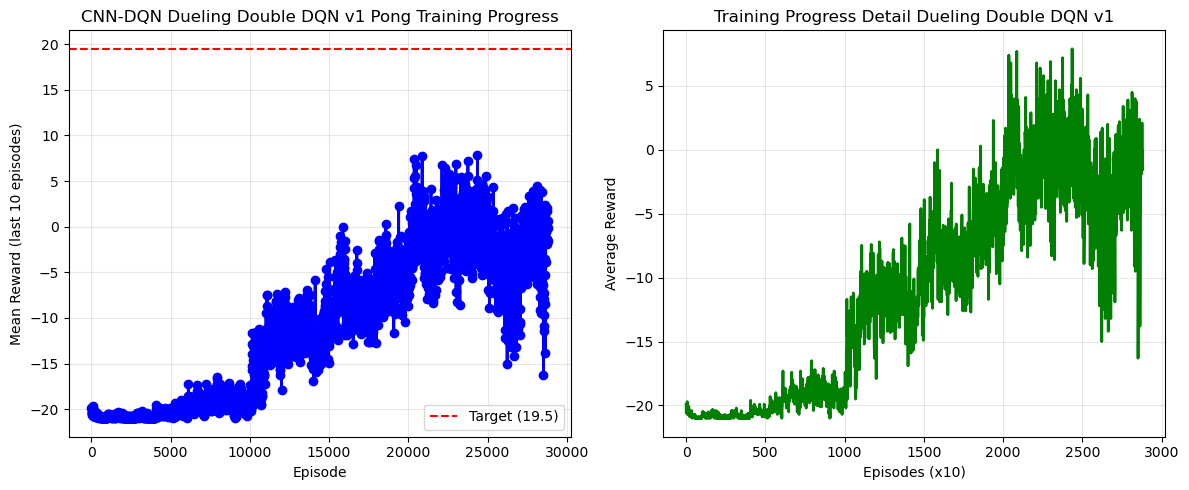

Episode 28810, Avg: -6.90, Mean(100): -0.91, Max: 21.00, ε: 0.010
Episode 28820, Avg: 0.20, Mean(100): -1.05, Max: 21.00, ε: 0.010
Episode 28830, Avg: -3.30, Mean(100): -1.17, Max: 21.00, ε: 0.010
Episode 28840, Avg: -2.70, Mean(100): -1.30, Max: 21.00, ε: 0.010


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7040a9d65bb0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7040a0101a60, execution_count=8 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7040a0101a30, raw_cell="# Ensure no active MLflow runs
if mlflow.active_ru.." transformed_cell="# Ensure no active MLflow runs
if mlflow.active_ru.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/bmartins/dev/rl_study/src/pong_dueling_dqn_cnn/pong_dueling_dqn_cnn_v1.ipynb#X15sZmlsZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [8]:
# Ensure no active MLflow runs
if mlflow.active_run():
    print("Ending active MLflow run...")
    mlflow.end_run()

# Train the Dueling Double DQN
trained_model = train_dueling_dqn()
print("Dueling Double DQN Training completed!")